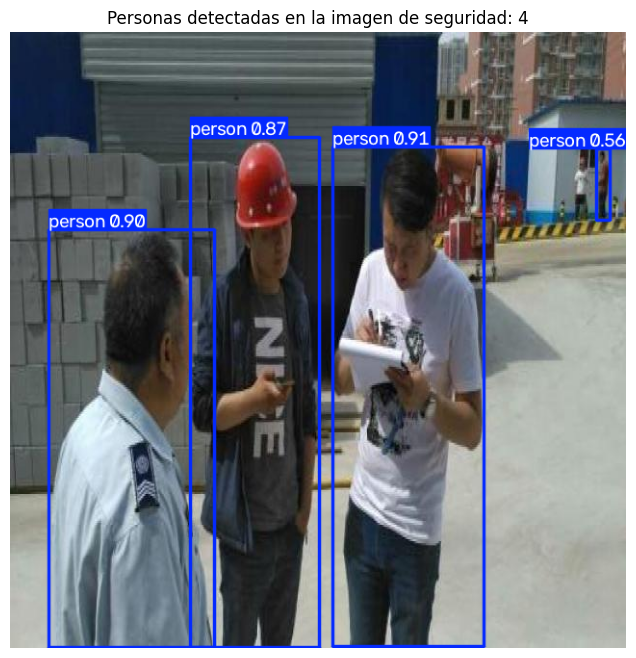

=== PERSONAS DETECTADAS EN LA IMAGEN DE TRABAJO ===
  [1] Persona | Confianza: 91% | Coordenadas: [335, 119, 492, 638]
  [2] Persona | Confianza: 90% | Coordenadas: [40, 205, 212, 639]
  [3] Persona | Confianza: 87% | Coordenadas: [187, 109, 321, 639]
  [4] Persona | Confianza: 56% | Coordenadas: [609, 121, 623, 195]


In [24]:
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Cargar el modelo preentrenado COCO
model_personas = YOLO("yolov8s.pt")

# 2. Usar la ruta de la imagen original de vest y helmet
IMAGEN_SITESAFETY = "/content/SiteSafety-1/test/images/00596_jpg.rf.069990c2f14e9a321e05f3d069869555.jpg"

# 3. Detectar solo personas (classes=[0]) con un umbral de confianza adecuado
resultados = model_personas(IMAGEN_SITESAFETY, conf=0.30, classes=[0], verbose=False)[0]

# 4. Mostrar la imagen anotada
imagen_anotada = resultados.plot()[:, :, ::-1]

plt.figure(figsize=(12, 8))
plt.imshow(imagen_anotada)
plt.title(f"Personas detectadas en la imagen de seguridad: {len(resultados.boxes)}")
plt.axis("off")
plt.show()

# 5. Listar los resultados
print("=== PERSONAS DETECTADAS EN LA IMAGEN DE TRABAJO ===")
if len(resultados.boxes) == 0:
    print("No se encontraron personas con confianza >= 30%.")
else:
    for i, box in enumerate(resultados.boxes, 1):
        conf = float(box.conf[0])
        coords = [int(c) for c in box.xyxy[0]]
        print(f"  [{i}] Persona | Confianza: {conf:.0%} | Coordenadas: {coords}")

Selecciona la imagen para detectar personas:


Saving Captura de pantalla 2025-09-22 225251.png to Captura de pantalla 2025-09-22 225251.png


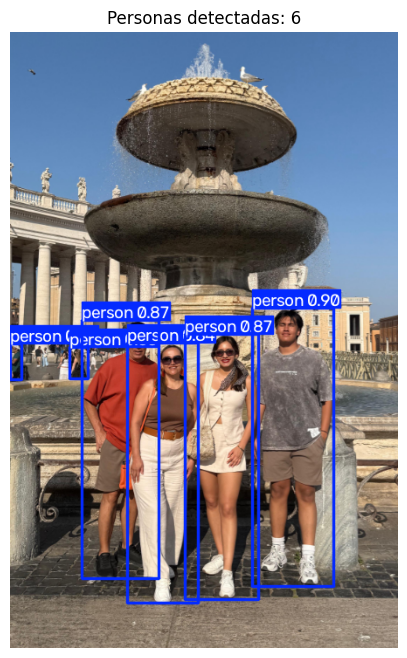

=== PERSONAS DETECTADAS ===
  [1] Persona | Confianza: 90% | Coordenadas: [277, 316, 370, 635]
  [2] Persona | Confianza: 87% | Coordenadas: [82, 330, 170, 626]
  [3] Persona | Confianza: 87% | Coordenadas: [200, 346, 284, 650]
  [4] Persona | Confianza: 84% | Coordenadas: [134, 356, 215, 654]
  [5] Persona | Confianza: 53% | Coordenadas: [68, 361, 89, 397]
  [6] Persona | Confianza: 30% | Coordenadas: [0, 357, 13, 398]


In [25]:
import PIL.Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files

# 1. Cargar el modelo preentrenado COCO (incluye la clase 'person')
model_personas = YOLO("yolov8s.pt")

# 2. Subir tu imagen desde la computadora
print("Selecciona la imagen para detectar personas:")
subidos = files.upload()

if subidos:
    ruta_imagen = list(subidos.keys())[0]

    # 3. Filtrar la inferencia UNICAMENTE para la clase 'person' (ID de clase 0 en COCO)
    # classes=[0] obliga al modelo a ignorar otros objetos (autos, sillas, etc.) y buscar solo personas
    resultados = model_personas(ruta_imagen, conf=0.30, classes=[0], verbose=False)[0]

    # 4. Dibujar los resultados
    imagen_anotada = resultados.plot()[:, :, ::-1]

    plt.figure(figsize=(12, 8))
    plt.imshow(imagen_anotada)
    plt.title(f"Personas detectadas: {len(resultados.boxes)}")
    plt.axis("off")
    plt.show()

    # 5. Listar las detecciones
    print("=== PERSONAS DETECTADAS ===")
    if len(resultados.boxes) == 0:
        print("No se encontraron personas con un nivel de confianza superior al 30%.")
    else:
        for i, box in enumerate(resultados.boxes, 1):
            confianza = float(box.conf[0])
            coords = [int(c) for c in box.xyxy[0]]
            print(f"  [{i}] Persona | Confianza: {confianza:.0%} | Coordenadas: {coords}")
else:
    print("No subiste ninguna imagen.")